### Helpful resources:
* [Guide to Markdown](https://paperhive.org/help/markdown)
* [Guide to LaTeX Math symbols](http://tug.ctan.org/info/undergradmath/undergradmath.pdf)
* [Python Cheat Sheets](https://ehmatthes.github.io/pcc/cheatsheets/README.html)
* [Moving to Python from MATLAB](https://bastibe.de/2013-01-20-a-python-primer-for-matlab-users.html)
---

# Lab #3: Harmonic analysis of the Precipitation
### Farhan Ariff bin Halis Azhan
### Collaborators
* Prof. Daniel Welling
* Name

## Goal and Introduction
Precipitations are one of important elements in Earth natural system.  
With precipitation, we can predict long term effect such as climate changes to short term like seasonal changes.  
With that being said, the goal of this lab is to analyze precipitation datasets over 67 years (804 months) using harmonic analysis.

## Data
The dataset that will be used are AnnArbor_Precip.csv. This file contain the total precipitation for Michigan in units of hundredths of inches per month, from year 1931 to 1997, which equals to 67 years of data. When reading the datasets into variable, we will ignore the first 4 headers and only use the columns from index three to index fourteen (based on zero-indexing), so we will only get the precipitation value for each month. Also, because the units is in hundredths of inches, we will want to change it into inches by dividing it by 100.

----

## Approach and Results
Here I put a code cell to import packages that will be used throughout this lab. 

In [1]:
# Import critical libraries:
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt
from dateutil.relativedelta import relativedelta
# Turn on in-line plotting:
%matplotlib inline

### Question 1
First off, we will read the datasets AnnArbor_Precip.csv into a variable data. As mentioned above in Data section, we will skip 4 headers and only use column from index 3 to index 14.
After doing that, we will be left with a data with matrix shape of (67 , 12).
To use this data, we will need to change it from matrix into a vector variable (data2), by using the flatten() function. This function will flatten a matrix into a vector row by row. We will also divide the data by 100 to change its unit from hundredths of inches into inches.

In [2]:
# read files
data = np.genfromtxt('./AnnArbor_Precip.csv', delimiter=',', skip_header=4, usecols= (3,4,5,6,7,8,9,10,11,12,13,14))
# print(data)
# print(data.shape)
data2 = data.flatten()
# The unit from the data is in hundredth of inches. 
# To change it into inches, divide by 100
data2 = data2/100
# print(data2)
# print(data2.shape)

After doing this, we will realize that we have a vector with only the value; we will not understand what time correspond to the value!  
To solve this, we will construct a time array that match to each value in the data.

In [3]:
# define a datetime vector with one month increment each
start = dt.datetime(1931,1,1)
time = [start + relativedelta(months=i) for i in range(0,(1997 - 1931 + 1)*12)]
# print(time)
# print(len(time))
# print(67*12)

Now we have both data2 vector and time vector, we will plot data2 against time, which will then show precipitation trend from January 1931 to December 1997.

Text(0.5, 1.0, 'Precipitation (inches) from 1931 to 1997 (in month)')

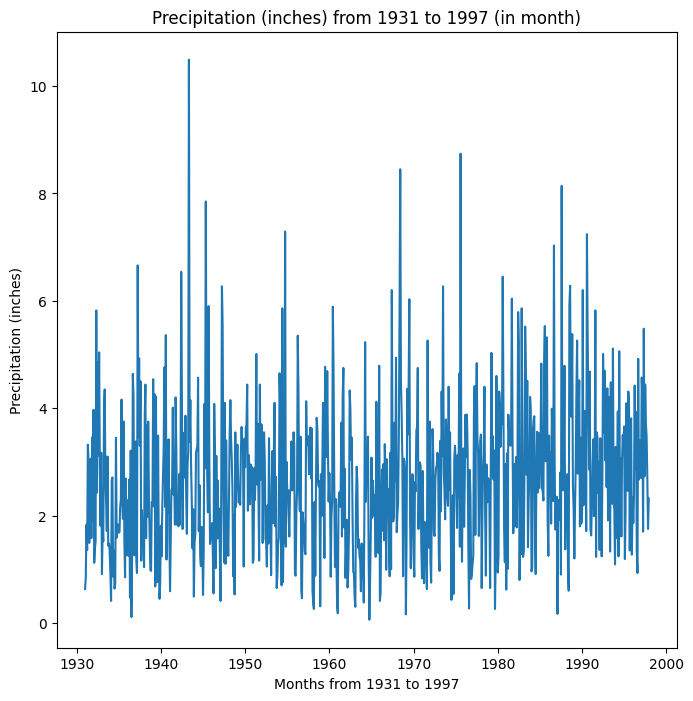

In [26]:
# plot precipitation against time (in month)
fig, axe = plt.subplots(figsize = (8,8))
# Plot the data
axe.plot(time, data2)

# Give label and titile
axe.set_xlabel("Months from 1931 to 1997")
axe.set_ylabel("Precipitation (inches)")
axe.set_title("Precipitation (inches) from 1931 to 1997 (in month)")

From this graph, we can see that there is a periodicity of the precipitation data; its cycle of events follows a consistent and predictable trend.

### Question 2
Now that we see that the datasets shows periodicity, we will use harmonic analysis to figure out the precipitation trend over frequency and period.  
To do harmonic analysis, we will need amplitude, phase angle, offset, time series, and frequency.   
First off, we will initialize offset and time series as a constant variable, as its value will not change over each harmonic.

In [5]:
# initialize offset 
offset = data2.mean()
# print(offset)
# initialize time vector
t = np.arange(data.size)
# t should be length of 804, because 67 years * 12 months
# print(len(t))

Then, we want to define a function to calculate amplitude and phase angle given datasets and integer k (for k-th harmonic)

(The below code was copied from Lecture 6 demos written by Prof. Daniel Welling. Any changes will be stated in the comment or markdown cell)

In [6]:
# Code copied from Lecture 6 demos written by Prof. Daniel Welling starts here
# Let's define some functions to calculate our Harmonic Coefficients:
def coeffs(x, k=1):
    '''
    For a data vector x that is evenly spaced with no missing values,
    calculate the coefficients A and B for the k-th harmonic.

    The amplitude and phase angle are returned.
    '''
    
    # Initial values:
    A, B = 0, 0
    
    # Number of values:
    nval = x.size

    for xi, i in zip(x, range(1, nval+1)):
        A += xi*np.cos(2*np.pi*k*i/nval)
        B += xi*np.sin(2*np.pi*k*i/nval)

    A *= 2/nval
    B *= 2/nval

    # Get amplitude, phase angle:
    C = np.sqrt(A**2 + B**2)
    phi = np.arctan2(B,A)

    return C, phi

Then, we will initialize three vector.
Two of the vectors' size will be half of the data2 size, complying to the full harmonic. Its name are amps, and freqs, which will be used to store the amplitude, and the frequency of the harmonic analysis for each k-iteration.
The last vector's size will be similar to the data2 size, named yharmonic, to store the harmonic value for each k-iteration.

In [27]:
# Keep frequency and amplitude for each harmonic.
freqs   = np.zeros(int(data2.size/2))
amps    = np.zeros(int(data2.size/2))
# Create array to hold the harmonic series:
y_harmonic = np.zeros(data2.size)

After doing the above, we will then loop from 1 to half of the datasets to make a full harmonic analysis.

In [8]:
# Loop over harmonics i=1 through npoints/2
for i in range(int(data2.size/2)):
    # Get current frequency:
    freq = 2*np.pi*(i+1) / len(data2)
    freqs[i] = freq

    # Get coeffs for this harmonic.
    # Note the '+1' to account for zero-based indexing in our loop.
    amp, phase = coeffs(data2, k=i+1)
    # Store amplitude:
    amps[i] = amp
    # print(amp)
    # Sum our cosine with the rest of our harmonics:
    y_harmonic += amp * np.cos(freq * t - phase)
# Finally, add offset:
y_harmonic += offset
# print(f"Harmonic Values : {y_harmonic}")

After that, we will plot a final full harmonic over the original data. If the harmonic plot seems similar to the original data, the algorithm was deemed successful.

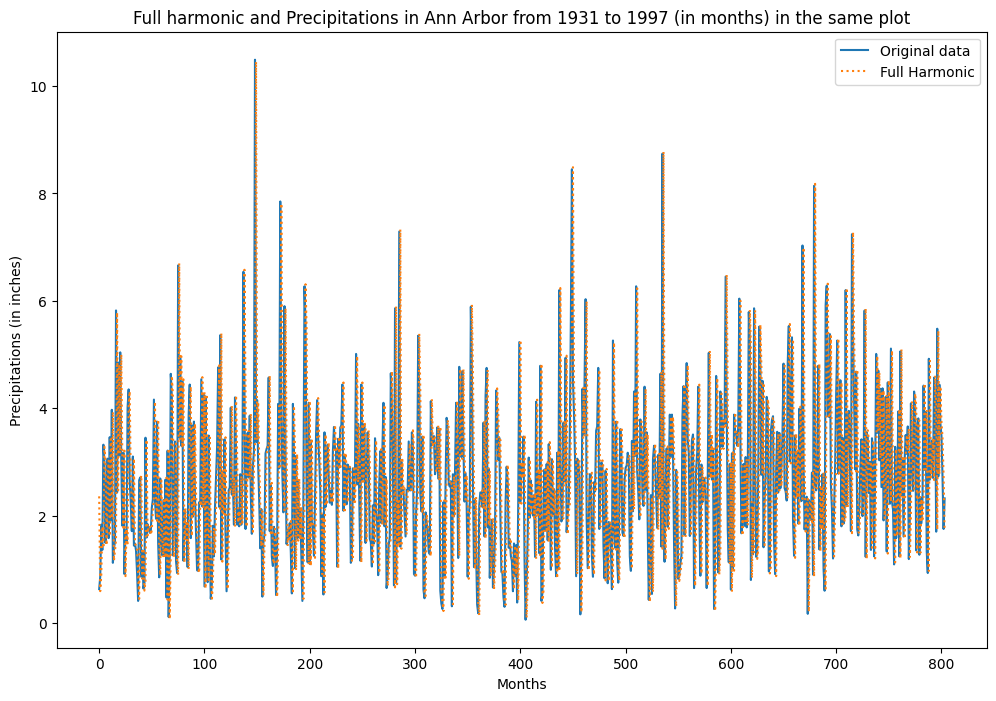

In [20]:
# Here we will plot the final full harmonic over the original data
fig = plt.figure(figsize=(12, 8))
ax1 = plt.subplot(111)


# First we plot the original dataset against the time vector
ax1.plot(t, data2, label='Original data')
# then, we plot the final full harmonic against the time vector over the same plot above
ax1.plot(t, y_harmonic, linestyle = 'dotted', label='Full Harmonic')

# Add labels and title:
ax1.set_title(f'Full harmonic and Precipitations in Ann Arbor from 1931 to 1997 (in months) in the same plot')
ax1.set_ylabel('Precipitations (in inches)')
ax1.set_xlabel('Months')
ax1.legend(loc='best')

# Code copied from lecture 6 demos written By Prof. Daniel Welling ends

(The above code was copied from Lecture 6 demos written by Prof. Daniel Welling. Any changes will be stated in the comment or markdown cell)

Both plots looks overlapping, which means the algorithm works as intended.

From the plot, we will want to find out its fundamental frequency and fundamental period.  
Fundamental frequency is the first harmonic's frequency, and the lowest frequeny we should have. It also correspond to the frequency of a wave whose period is equal to the total span of the data set.  
Fundamental frequency will tell us how many cycles will be done in one time unit (in first harmonic case, 804 months).  
Fundamental period is the first harmonic's period, and the highest period we should have. Fundamental period will tell us how many time unit (in first harmonic case, 804 months) will occur in one cycle.

Fundamental frequency of this data set is 0.001244 Hz while the fundamental period is 804 months per cycle.

In [10]:
freq = 1/data2.size
print(freq)

period = 1/freq
print(period)

0.0012437810945273632
804.0


### Question 3
In harmonic analysis, large amplitude will explain more fraction of the monthly precipitation variance of that harmonic frequency.  
In other words, we can think that the largest amplitude can explain the most fraction of the monthly precipitation variance.  
Now, we want to find the largest amplitude and the second largest amplitude,   
but before that, we want to plot a graph of amplitude against the log of period in year (the formula for period here being 2 $pi$ / frequency/ 12 months).

Text(0, 0.5, 'Amplitude (inches of precip)')

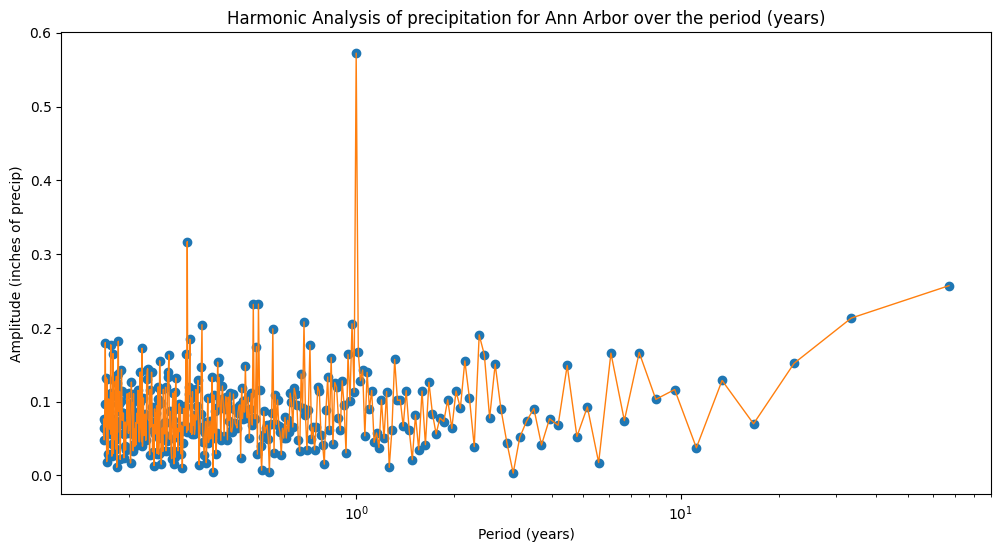

In [22]:
fig = plt.figure(figsize=(12,6))
ax = fig.add_subplot(111)   
# change frequency to period
# the period then divided by 12 to change from months into year
ax.semilogx((2*np.pi)/(freqs)/12, amps, 'o')
ax.semilogx((2*np.pi)/(freqs)/12, amps, '-', lw=1)

# give title, xlabel, ylabel into axis 
ax.set_title('Harmonic Analysis of precipitation for Ann Arbor over the period (years)')
ax.set_xlabel('Period (years)')
ax.set_ylabel('Amplitude (inches of precip)')

After seeing the graph, we will now attempt to find the index of the highest and second highest amplitude using np.argmax() function.

In [12]:
# finding the largest and second largest amplitudes
import copy
# The index for the largest amplitude
largest_amp_index = np.argmax(amps)
print(f"The index for the largest amplitude is : {largest_amp_index}")

# making a deepcopy for amps vector so that its value will not accidentally be tampered
amps2 = copy.deepcopy(amps)

# set the value for the largest amplitude to be 0, so now we can find the second largest amplitude from the copied vecctor
amps2[largest_amp_index] = 0

# The index for the second largest amplitude
sec_largest_amp_index = np.argmax(amps2)
print(f"The index for the second largest amplitude is : {sec_largest_amp_index}")

The index for the largest amplitude is : 66
The index for the second largest amplitude is : 221


Using these index, we can then find the frequency that correspond to the largest and second largest amplitude.  

In [13]:
# Frequency for the largest amplitude
freq_for_largest_amp = freqs[largest_amp_index]
print(f"The angular frequency for the largest amplitude is : {freq_for_largest_amp}")
print(f"The physical frequency for the largest amplitude is : {freq_for_largest_amp/(2*np.pi)}")

# Frequency for the second largest amplitude
freq_for_sec_largest_amp = freqs[sec_largest_amp_index]
print(f"The angular frequency for the second largest amplitude is : {freq_for_sec_largest_amp}")
print(f"The physical frequency for the second largest amplitude is : {freq_for_sec_largest_amp/(2*np.pi)}")


The angular frequency for the largest amplitude is : 0.5235987755982988
The physical frequency for the largest amplitude is : 0.08333333333333333
The angular frequency for the second largest amplitude is : 1.73490937586302
The physical frequency for the second largest amplitude is : 0.27611940298507465


In [14]:
# Period for the largest amplitude
print(f"The period for the largest amplitude is : {2*np.pi/freq_for_largest_amp}")

# Period for the second largest amplitude
print(f"The period for the second largest amplitude is : {2*np.pi/freq_for_sec_largest_amp}")

The period for the largest amplitude is : 12.0
The period for the second largest amplitude is : 3.6216216216216215


The physical frequency that explain the largest fraction of monthly precipitation variance is 0.083, while its angular frequency is 0.524. The period that correspond to these frequency is 12.0 months per cycle.

The physical frequency that explain the second largest fraction of monthly precipitation variance is 0.276, while its angular frequency is 1.735. The period that correspond to these frequency is 3.622 months per cycle.

In my opinion, these frequency makes sense in terms of the natural causes of variability of rainfall are because a frequency of 0.083 HZ equal to a period of 12 months per cycle, which means between years, the characteristic of the precipitation will differ.  
I think these difference in characteristic of precipitation happen was also because there might be a trend of global warming in these years, which lead to abnormal weather, thus different precipitation.  

In other hands, the period for the second largest amplitude is 3.62 months per cycle, which means there are difference in precipitation for each 3.62 months cycle.  
I think this makes sense because every 3 to 4 seasons, Ann Arbor will experience seasonal change, and with this seasonal change, difference in total value of precipitation.

### Question 4
Now we will put our focus on the 67-th harmonic, with k being the index that correspond to the largest amplitude we got from question 3, which is 66.  
We are using 67th harmonic(we will call it yharmonic2) because its amplitude is the highest, which should also explain the most fraction of the precipitation variance in the datasets.  
We will use the same code as above, the one that we copied from Professor Daniel Welling, with the only changes being we will stop the iteration when i (starting from 0) reach the index of largest amplitude to find the 67-th harmonic.

In [15]:
freqs2   = np.zeros(int(data2.size/2))
amps2  = np.zeros(int(data2.size/2))

y_harmonic2 = np.zeros(data2.size)
# Loop over harmonics i=1 through the index of the largest amplitude
for i in range(largest_amp_index):
    # Get current frequency:
    freq = 2*np.pi*(i+1) / len(data2)
    freqs2[i] = freq

    # Get coeffs for this harmonic.
    # Note the '+1' to account for zero-based indexing in our loop.
    amp, phase = coeffs(data2, k=i+1)
    # Store amplitude:
    amps2[i] = amp
    # Sum our cosine with the rest of our harmonics:
    y_harmonic2 += amp * np.cos(freq * t - phase)
y_harmonic2 += offset

First off, we will plot the harmonic over the original datasets.



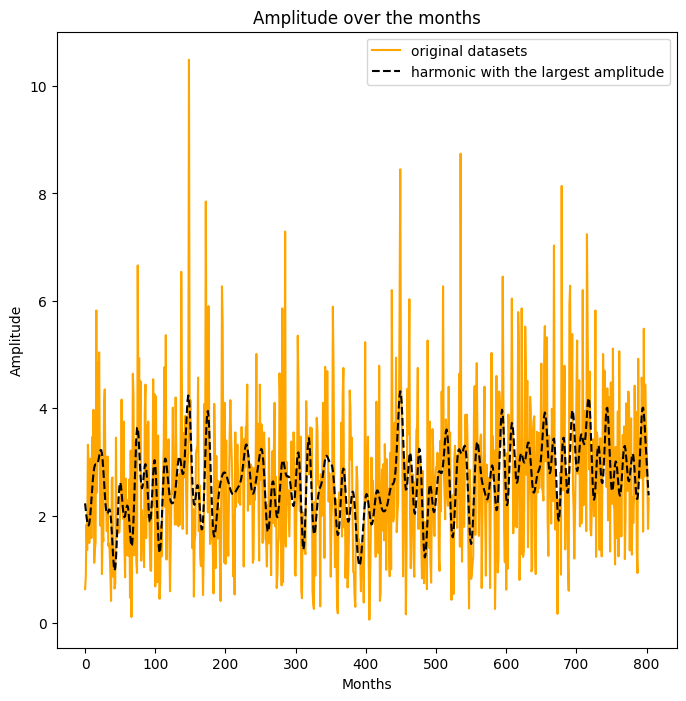

In [24]:
fig = plt.figure(figsize=(8, 8))
ax1 = plt.subplot(111)
ax1.plot(t, data2, color = 'orange', label = 'original datasets')
ax1.plot(t, y_harmonic2, '--', color = 'black', label ='harmonic with the largest amplitude')
# Add labels and title:
ax1.set_title(f'Amplitude over the months')
ax1.set_ylabel('Amplitude')
ax1.set_xlabel('Months')
ax1.legend(loc='best')

After that, we will plot the difference between these two vectors

Text(0.5, 0, 'Months')

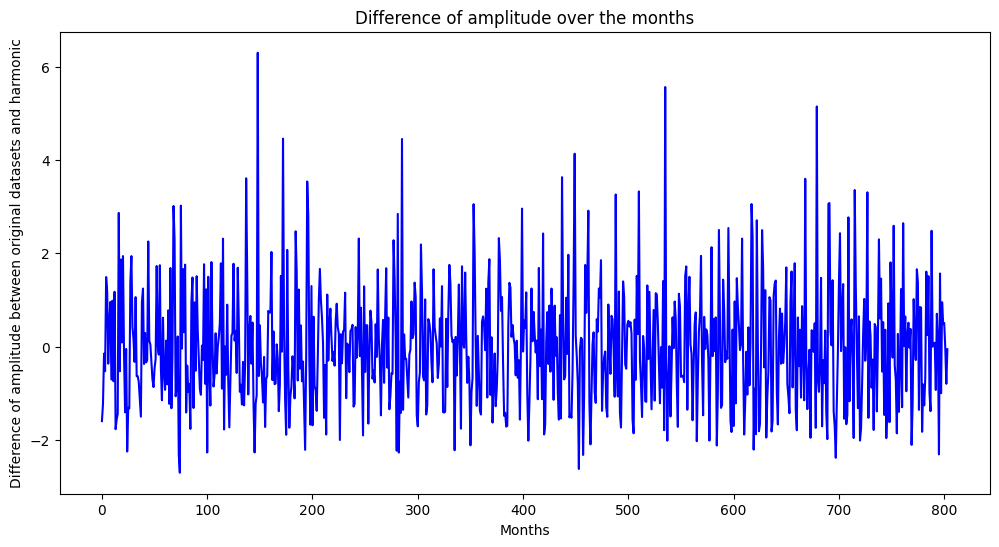

In [25]:
# Create a two-frame figure:
fig = plt.figure(figsize=(12, 6))
ax1 = plt.subplot(111)

# Compute the difference between original dataset and the harmonic for the largest amplitude
diff = data2 - y_harmonic2
# Plot lines, one above the other:
ax1.plot(t, diff, color = 'blue')
# Add labels and title:
ax1.set_title(f'Difference of amplitude over the months')
ax1.set_ylabel('Difference of amplitude between original datasets and harmonic')
ax1.set_xlabel('Months')

Shockingly, from the plot of the difference against the time, we can see there is a large difference of value across the time.   
Which means, even though we are using the harmonic with the largest amplitude, the fraction of precipitation variance it explains are still small and unsatisfactory.

To see it in statistical term, we then try to find the value of $R^{2}$ between the original dataset and the 67-th harmonic, as $R^{2}$ can tells us the fraction of the variance of the original dataset that can be explained by the variance of the (k+1)-th harmonic.

In [18]:
coeff = np.corrcoef(data2, y_harmonic2)
print(coeff)
print(coeff[0,1] ** 2)

[[1.         0.41893146]
 [0.41893146 1.        ]]
0.17550356810891973


From above, we have achieved $R^{2}$ with value of 0.176, which means the harmonic frequency with the highest amplitude can only explain 17.6% of the precipitation variance. This is, again, shockingly a small value. 
The reason $R^{2}$ evaluates to such low value can be contributed to two reasons, which are, the fact that said measurement is not a robust or resilient measure of covariance, and the characteristics of the datasets. These two reasons are related to each other.  


The measurement $R^{2}$ being not a robust or resilient measurement means that it is easily influenced to outliers, and it was designed to measure linearity and will have difficulty against non-linearity.  
In other hands, the precipitation data has all these characterictics that make $R^{2}$ not a suitable measurement to be used.  
The precipitation data has a lot of outlier, with certain month has the highest or lowest amount of precipitation that significantly differ from the mean.  
These outlier in turn messed up the  $R^{2}$ values.  
Besides that, from the graph we created in q1, it clearly shows that the graph is not linear, which means the residuals are not normally distributed.  
The residuals not normally distributed then will make $R^{2}$ not a good measurement to fit the data.  
Thus, in my opinion, the application of $R^{2}$ is not proper to the characteristics of the dataset.

## Conclusions
From this lab, we see that the precipitation follows a consistent trend. More accurately, its trend repeat/cycle for each 12 months or 3.6 months. This might happen because for each year, it will experience the whole seasonal changes from January to December, or because for each 3.6 months, it experience seasonal change that will make the precipitation dataset differ for each cycle. 

From this lab too, we can see that $R^{2}$ was not a good measurement to fit the precipitation datasets, as the datasets display outliers and non-linearity. These characteristics will worsen the measurement's fit.

## References
List any references used